In [1]:
from langgraph.graph import StateGraph,START,END
import os
from dotenv import load_dotenv
from typing import TypedDict
from langchain_google_genai import ChatGoogleGenerativeAI


In [2]:
# Initialize Gemini
load_dotenv()
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    google_api_key=os.getenv("GOOGLE_API_KEY")
)

In [8]:
# state 

class BatsmanState(TypedDict):

    runs : int
    balls : int
    fours : int 
    sixes : int 

    sr : float
    bpb : float # ball per boundry 
    boundary_percent : float
    summary : str

In [ ]:
# nodes
def calculate_sr(state:BatsmanState)-> BatsmanState:
    sr = (state['runs'] / state['balls']) * 100
    return {'sr':sr}


def calucate_bpb(state:BatsmanState) -> BatsmanState:
    bpb= state['balls'] / (state['fours'] + state['sixes'])
    return {'bpb':bpb}


def calculate_boundary_percent(state:BatsmanState)->BatsmanState:
    boundary_percent = ((state['fours']*4) + (state['sixes']*6)) / (state['runs']) * 100
    return {'boundary_percent':boundary_percent}

def summary(state:BatsmanState)-> BatsmanState:

    cricket_summary = f"strike rate : {state['sr']}/n ball per boundary : {state['bpb']} /n boundary percent : {state['boundary_percent']}"
    
    return {'summary':cricket_summary}



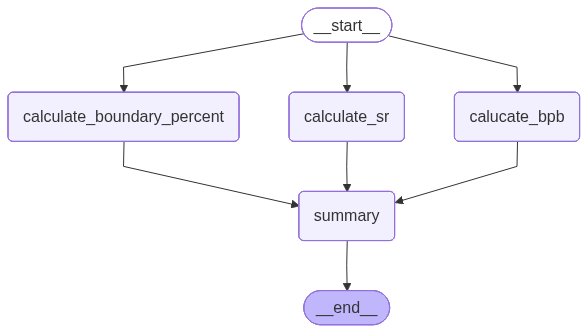

In [12]:
graph = StateGraph(BatsmanState)
graph.add_node("calculate_sr",calculate_sr)
graph.add_node("calucate_bpb",calucate_bpb)
graph.add_node("calculate_boundary_percent",calculate_boundary_percent)
graph.add_node("summary",summary)


graph.add_edge(START,'calculate_sr')
graph.add_edge(START,'calucate_bpb')
graph.add_edge(START,'calculate_boundary_percent')

graph.add_edge('calculate_sr','summary')
graph.add_edge('calucate_bpb','summary')
graph.add_edge('calculate_boundary_percent','summary')
graph.add_edge('summary',END)

graph.compile()



    